<a href="https://colab.research.google.com/github/Tanxinru05/mem-gnn-rnn-continuous-prediction/blob/main/power_plant_tgat_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
import os
import pickle
from sklearn.preprocessing import StandardScaler # Changed to MinMaxScaler
from zipfile import ZipFile
from io import BytesIO

# --- Configuration ---
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
TARGET_COLUMN = 'PE' # Net hourly electrical energy output

def create_tgat_data():
    print("--- 1. Loading Power Plant Data ---")
    if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
        print("Downloading data...")
        response = requests.get(DATA_URL); response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as z: z.extractall()

    df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    print("--- 2. Engineering Static Node Features ---")
    all_columns = df.columns.tolist()
    node_map = {name: i for i, name in enumerate(all_columns)}
    num_nodes = len(all_columns)

    node_features = np.zeros((num_nodes, 4))
    for i, col in enumerate(all_columns):
        node_features[i, 0] = df[col].mean(); node_features[i, 1] = df[col].std()
        node_features[i, 2] = df[col].min(); node_features[i, 3] = df[col].max()

    # --- CHANGE: Using MinMaxScaler for consistency ---
    node_features = StandardScaler().fit_transform(node_features)
    np.save('nodes_power_tgat.npy', node_features)

    print("--- 3. Creating Event Data and Adjacency List ---")
    df['ts'] = np.arange(len(df)) # Create a synthetic timestamp

    target_df = df[['ts', TARGET_COLUMN]].copy()
    target_df['node_id'] = node_map[TARGET_COLUMN]
    target_df.rename(columns={TARGET_COLUMN: 'demand'}, inplace=True)
    target_df[['ts', 'node_id', 'demand']].to_csv('events_power_tgat.csv', index=False)

    feature_df = df.drop(columns=[TARGET_COLUMN])
    adj_list = {node_map[TARGET_COLUMN]: []}

    for col in tqdm(feature_df.drop(columns=['ts']).columns, desc="Building Adjacency List"):
        feature_node_id = node_map[col]
        for row in feature_df[['ts', col]].itertuples():
            adj_list[node_map[TARGET_COLUMN]].append((feature_node_id, row.ts))

    with open('adj_list_power_tgat.pkl', 'wb') as f:
        pickle.dump(adj_list, f)
    print("\nPreprocessing complete for TGAT models.")

if __name__ == '__main__':
    create_tgat_data()

--- 1. Loading Power Plant Data ---
--- 2. Engineering Static Node Features ---
--- 3. Creating Event Data and Adjacency List ---


Building Adjacency List: 100%|██████████| 4/4 [00:00<00:00, 40.50it/s]


Preprocessing complete for TGAT models.


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # <-- CHANGED: Using StandardScaler for more robust scaling
import matplotlib.pyplot as plt
import os
import pickle
from collections import defaultdict
from tqdm import tqdm
import sys
import requests
from zipfile import ZipFile
from io import BytesIO


# --- Configuration (Tuned for High Performance) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128         # <-- CHANGED: Increased capacity for more complex input
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2       # <-- CHANGED: Adjusted for a more powerful model
N_RUNS = 2               # Set to 1 for a single, definitive run
EPOCHS = 100             # <-- CHANGED: Increased epochs for better convergence
BATCH_SIZE = 256         # <-- CHANGED: Larger batch size for stable training
PATIENCE = 15            # <-- CHANGED: More patience as the model learns more
LEARNING_RATE = 0.001    # <-- CHANGED: Slightly higher LR is fine with the better signal
WARMUP_EPOCHS = 5
NUM_NEIGHBORS = 4        # There are 4 feature nodes per timestamp

# --- Helper Functions and Classes ---
def plot_loss(h, model_name, run):
    plt.figure(figsize=(10, 5))
    plt.plot(h['train'], label='Train Loss')
    plt.plot(h['val'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss')
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_loss.png"); plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10))
    plt.scatter(yt, yp, alpha=0.3, edgecolors='k', s=20)
    plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2, label='Ideal Fit')
    plt.title(f'{model_name} - Run {run} - Predictions (R2: {r2_score(yt, yp):.4f})')
    plt.xlabel("Actual Values"); plt.ylabel("Predicted Values")
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_predictions.png"); plt.close()

class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        out_ngh_ts_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.float64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = sorted([n for n in neighbors if n[1] <= cut_time],
                                      key=lambda x: x[1],
                                      reverse=True)[:num_neighbors]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
                out_ngh_ts_batch[i, :len(recent_neighbors)] = [x[1] for x in recent_neighbors]
        return out_ngh_node_batch, out_ngh_ts_batch

class SinusoidalTimeEncode(nn.Module):
    def __init__(self, dimension):
        super().__init__(); self.dimension = dimension
    def forward(self, t):
        t = t.unsqueeze(dim=-1)
        div = torch.exp(torch.arange(0, self.dimension, 2, device=DEVICE).float() * -(np.log(10000.0) / self.dimension))
        pe = torch.zeros(*t.shape[:2], self.dimension, device=DEVICE)
        pe[..., 0::2] = torch.sin(t * div); pe[..., 1::2] = torch.cos(t * div)
        return pe

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.t_proj = nn.Linear(feat_dim, feat_dim); self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat, t_enc):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        t = self.t_proj(t_enc).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum((q * k) + t, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

# --- HIGH-PERFORMANCE HYBRID MODEL ---
class TGAT_BiLSTM_MHSA(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout, bilstm_h, num_direct_features):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.node_features = torch.nn.Parameter(node_features, requires_grad=False)
        self.embed_dim = bilstm_h * 2 # Align dimensions

        # Part 1: Your original TGAT architecture
        self.feat_proj = nn.Linear(feat_dim, self.embed_dim)
        self.time_enc = SinusoidalTimeEncode(self.embed_dim)
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(self.embed_dim, n_heads, dropout) for _ in range(n_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(self.embed_dim) for _ in range(n_layers)])
        self.bilstm = nn.LSTM(self.embed_dim, bilstm_h, batch_first=True, bidirectional=True)
        self.mhsa = nn.MultiheadAttention(bilstm_h * 2, num_heads=n_heads, batch_first=True, dropout=dropout)
        self.seq_norm = nn.LayerNorm(bilstm_h * 2)

        # <-- CHANGED: Part 2: A small MLP to process the direct, per-timestamp features
        self.direct_feature_proj = nn.Sequential(
            nn.Linear(num_direct_features, bilstm_h),
            nn.ReLU(),
            nn.Linear(bilstm_h, bilstm_h * 2)
        )

        # <-- CHANGED: Part 3: A powerful regression head that combines both information sources
        self.reg_head = nn.Sequential(
            nn.Linear(bilstm_h * 4, bilstm_h * 2), # Input size is doubled
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(bilstm_h * 2, bilstm_h),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(bilstm_h, 1)
        )

    def forward(self, src_nodes, timestamps, direct_features): # <-- CHANGED: Takes direct features as input
        # --- TGAT Path ---
        src_feat = self.feat_proj(self.node_features[src_nodes])
        layer_outputs = []
        for i in range(len(self.attn_layers)):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1)
            t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE)
            t_enc = self.time_enc(t_deltas); mask = (ngh_idx_t != 0).unsqueeze(-1)
            agg_embed = self.attn_layers[i](src_feat, ngh_feat * mask, t_enc)
            src_feat = self.norm_layers[i](agg_embed + src_feat)
            layer_outputs.append(src_feat)

        tgat_sequence = torch.stack(layer_outputs, dim=1)
        bilstm_out, _ = self.bilstm(tgat_sequence)
        mhsa_out, _ = self.mhsa(bilstm_out, bilstm_out, bilstm_out)
        final_sequence = self.seq_norm(bilstm_out + mhsa_out)
        graph_representation = torch.mean(final_sequence, dim=1)

        # --- Direct Feature Path ---
        direct_representation = self.direct_feature_proj(direct_features)

        # --- Combine and Predict ---
        combined_representation = torch.cat([graph_representation, direct_representation], dim=1)
        return self.reg_head(combined_representation)

def train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, run_number):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    warmup_scheduler = LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e + 1) / WARMUP_EPOCHS))
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
    criterion = nn.MSELoss()
    best_val_loss, patience_counter, history = float('inf'), 0, defaultdict(list)

    for epoch in range(EPOCHS):
        model.train(); epoch_loss = 0
        # <-- CHANGED: Unpack the new direct_features tensor from the loader
        for node_ids, ts, direct_features, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            optimizer.zero_grad()
            node_ids, ts, direct_features, y = node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE), y.to(DEVICE)
            pred = model(node_ids, ts, direct_features) # <-- CHANGED: Pass features to model
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        history['train'].append(epoch_loss / len(train_loader))

        model.eval(); val_loss = 0
        with torch.no_grad():
            for node_ids, ts, direct_features, y in val_loader:
                pred = model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE)) # <-- CHANGED
                val_loss += criterion(pred, y.to(DEVICE)).item()
        avg_val_loss = val_loss / len(val_loader)
        history['val'].append(avg_val_loss)
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {history['train'][-1]:.4f} | Val Loss: {avg_val_loss:.4f}")

        if epoch < WARMUP_EPOCHS: warmup_scheduler.step()
        else: cosine_scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            torch.save(model.state_dict(), f'best_{model_name}_{run_number}.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"   -> Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f'best_{model_name}_{run_number}.pth')); model.eval(); preds, truths = [], []
    with torch.no_grad():
        for node_ids, ts, direct_features, y in test_loader:
            preds.append(model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE)).cpu()) # <-- CHANGED
            truths.append(y.cpu())

    preds_inv = target_scaler.inverse_transform(torch.cat(preds).numpy())
    truths_inv = target_scaler.inverse_transform(torch.cat(truths).numpy())

    plot_loss(history, model_name, run_number)
    plot_predictions(truths_inv, preds_inv, model_name, run_number)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_number, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

if __name__ == '__main__':
    # --- DATA LOADING AND PREPARATION ---
    try:
        # Load pre-computed graph files
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)

        # <-- CHANGED: Load the ORIGINAL dataset to get per-timestamp features
        DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading original CCPP data..."); response = requests.get(DATA_URL); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    except FileNotFoundError:
        print("❌ ERROR: Data not found. Please run the preprocessing script first."); sys.exit()

    # Prepare target variable and scalers
    target = original_df[['PE']].values
    direct_features = original_df[['AT', 'V', 'AP', 'RH']].values

    # Use StandardScaler for better performance
    feature_scaler = StandardScaler().fit(direct_features)
    target_scaler = StandardScaler().fit(target)

    direct_features_scaled = feature_scaler.transform(direct_features)
    target_scaled = target_scaler.transform(target)

    # Prepare graph-related data
    node_ids = np.full(len(original_df), 4) # Node ID for 'PE' is 4
    timestamps = np.arange(len(original_df))

    # <-- CHANGED: Create a new, richer TensorDataset
    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    full_ds = TensorDataset(torch.from_numpy(node_ids).long(),
                              torch.from_numpy(timestamps).float(),
                              torch.from_numpy(direct_features_scaled).float(),
                              torch.from_numpy(target_scaled).float())

    train_size = int(len(original_df) * 0.7); val_size = int(len(original_df) * 0.15)
    train_ds = Subset(full_ds, range(train_size))
    val_ds = Subset(full_ds, range(train_size, train_size + val_size))
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))

    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=4)
    val_loader = DataLoader(val_ds, BATCH_SIZE, pin_memory=True, num_workers=4)
    test_loader = DataLoader(test_ds, BATCH_SIZE, pin_memory=True, num_workers=4)

    neighbor_finder = NeighborFinder(adj_list); feat_dim = node_features.shape[1]

    model_name = "Hybrid_TGAT_High_Performance"
    model_args = {'neighbor_finder': neighbor_finder, 'node_features': node_features, 'feat_dim': feat_dim,
                  'n_layers': N_LAYERS, 'n_heads': N_HEADS, 'dropout': DROPOUT_RATE, 'bilstm_h': HIDDEN_DIM,
                  'num_direct_features': direct_features.shape[1]}

    print(f"\n--- Starting Run for {model_name} ---")
    model = TGAT_BiLSTM_MHSA(**model_args).to(DEVICE)
    metrics = train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, 1)

    print("\n\n" + "="*80 + f"\n--- 🏁 FINAL {model_name} RESULTS ---\n" + "="*80)
    final_results_df = pd.DataFrame([metrics])
    for col in ['MSE', 'RMSE', 'R2']:
        final_results_df[col] = final_results_df[col].apply(lambda x: f"{x:.4f}")
    print(final_results_df.to_string(index=False))

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



--- Starting Run for Hybrid_TGAT_High_Performance ---


Epoch 1:   0%|          | 0/27 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch 1/100 | Train Loss: 0.4815 | Val Loss: 0.1354


Epoch 2/100 | Train Loss: 0.0980 | Val Loss: 0.0706


...

Epoch 70/100 | Train Loss: 0.0543 | Val Loss: 0.0618


Epoch 71/100 | Train Loss: 0.0546 | Val Loss: 0.0618


Epoch 72/100 | Train Loss: 0.0541 | Val Loss: 0.0622


Epoch 73/100 | Train Loss: 0.0549 | Val Loss: 0.0626


Epoch 74/100 | Train Loss: 0.0542 | Val Loss: 0.0628
   -> Early stopping at epoch 74


--- 🏁 FINAL Hybrid_TGAT_High_Performance RESULTS ---
                       Model  Run     MSE   RMSE     R2
Hybrid_TGAT_High_Performance    1 16.3485 4.0433 0.9420


In [ ]:
!zip -r /content/powerplant_proposed_4_runs.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2025.07.29/ (stored 0%)
  adding: content/.config/logs/2025.07.29/13.36.27.119914.log (deflated 58%)
  adding: content/.config/logs/2025.07.29/13.36.15.785307.log (deflated 57%)
  adding: content/.config/logs/2025.07.29/13.36.25.001588.log (deflated 86%)
  adding: content/.config/logs/2025.07.29/13.36.37.567476.log (deflated 56%)
  adding: content/.config/logs/2025.07.29/13.35.49.066514.log (deflated 92%)
  adding: content/.config/logs/2025.07.29/13.36.36.776594.log (deflated 57%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 22%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: co

In [ ]:
from google.colab import files
files.download('/content/powerplant_proposed_4_runs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# TGAT_Only_Optimized_with_R2_Curve.py

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import pickle
from collections import defaultdict
from tqdm import tqdm
import sys
import requests
from zipfile import ZipFile
from io import BytesIO

# --- Optimized Hyperparameters ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
N_RUNS = 1
EPOCHS = 100
BATCH_SIZE = 256
PATIENCE = 15
LEARNING_RATE = 0.001
WARMUP_EPOCHS = 5
NUM_NEIGHBORS = 4

# --- Helper Functions and Classes ---
def plot_learning_curves(h, model_name, run):
    """Plots the learning curves for training and validation loss."""
    plt.figure(figsize=(10, 6))
    plt.plot(h['train_loss'], label='Train Loss')
    plt.plot(h['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Run {run} - Loss Learning Curve', fontsize=16)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_loss_curve.png"); plt.show(); plt.close()

# <<< NEW: Function to plot the R-squared learning curve >>>
def plot_r2_curves(h, model_name, run):
    """Plots the R-squared curves for training and validation sets."""
    plt.figure(figsize=(10, 6))
    plt.plot(h['train_r2'], label='Train R-squared')
    plt.plot(h['val_r2'], label='Validation R-squared')
    plt.title(f'{model_name} - Run {run} - R-Squared ($R^2$) Learning Curve', fontsize=16)
    plt.xlabel('Epochs')
    plt.ylabel('R-squared Score')
    plt.ylim(min(0, np.min(h['val_r2'])-0.1), 1.0) # Sensible y-axis for R2
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_r2_curve.png"); plt.show();plt.close()

def plot_predictions(yt, yp, model_name, run):
    plt.figure(figsize=(10, 10))
    plt.scatter(yt, yp, alpha=0.3, edgecolors='k', s=20)
    plt.plot([yt.min(), yt.max()], [yt.min(), yt.max()], '--r', linewidth=2, label='Ideal Fit')
    plt.title(f'{model_name} - Run {run} - Predictions (R2: {r2_score(yt, yp):.4f})')
    plt.xlabel("Actual Values"); plt.ylabel("Predicted Values")
    plt.legend(); plt.grid(True); plt.savefig(f"{model_name}_power_run{run}_predictions.png");plt.show(); plt.close()

class NeighborFinder:
    def __init__(self, adj_list):
        self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            # Find neighbors that occurred at the exact same timestamp
            recent_neighbors = [n for n in neighbors if n[1] == cut_time]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]
        return out_ngh_node_batch

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads
        self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3))
        self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat):
        b, n_ngh, _ = ngh_feat.size()
        q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2)
        k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3)
        scores = torch.sum(q * k, dim=-1) / np.sqrt(self.d)
        attn = torch.softmax(scores, dim=-1)
        out = torch.sum(attn.unsqueeze(-1) * v, dim=2)
        return self.dropout(self.o_proj(out.view(b, -1)))

# --- MODEL DEFINITION FOR TGAT_Only ---
class TGAT_Only(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout):
        super().__init__()
        self.neighbor_finder = neighbor_finder
        self.node_features = torch.nn.Parameter(node_features, requires_grad=False)
        self.feat_dim = feat_dim
        self.attn_layers = nn.ModuleList([TemporalAttentionLayer(feat_dim, n_heads, dropout) for _ in range(n_layers)])
        self.norm_layers = nn.ModuleList([nn.LayerNorm(feat_dim) for _ in range(n_layers)])
        self.reg_head = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.GELU(),
            nn.Linear(feat_dim // 2, 1)
        )

    def forward(self, src_nodes, timestamps, direct_features): # Must accept all args from loader
        src_feat = self.node_features[src_nodes]
        for i in range(len(self.attn_layers)):
            ngh_idx = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS)
            ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE)
            ngh_feat = self.node_features[ngh_idx_t.flatten()].view(len(src_nodes), -1, self.feat_dim)
            agg = self.attn_layers[i](src_feat, ngh_feat)
            src_feat = self.norm_layers[i](agg + src_feat) # Residual connection
        return self.reg_head(src_feat)

# <<< MODIFIED: This function now calculates and stores R2 scores each epoch >>>
def train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, run_number):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    warmup_scheduler = LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, (e + 1) / WARMUP_EPOCHS))
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
    criterion = nn.MSELoss()
    best_val_loss, patience_counter, history = float('inf'), 0, defaultdict(list)

    for epoch in range(EPOCHS):
        model.train(); epoch_loss = 0
        for node_ids, ts, direct_features, y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
            optimizer.zero_grad()
            node_ids, ts, direct_features, y = node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE), y.to(DEVICE)
            pred = model(node_ids, ts, direct_features)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        history['train_loss'].append(epoch_loss / len(train_loader))

        # --- Calculate R2 for both train and validation sets each epoch ---
        model.eval()
        val_loss = 0
        train_preds, train_truths = [], []
        val_preds, val_truths = [], []

        with torch.no_grad():
            # R2 on training set (can be slow)
            for node_ids, ts, direct_features, y in train_loader:
                pred = model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE))
                train_preds.append(pred.cpu().numpy())
                train_truths.append(y.cpu().numpy())

            # R2 on validation set
            for node_ids, ts, direct_features, y in val_loader:
                pred = model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE))
                val_preds.append(pred.cpu().numpy())
                val_truths.append(y.cpu().numpy())
                val_loss += criterion(pred, y.to(DEVICE)).item()

        # Calculate and store metrics for the epoch
        train_r2 = r2_score(np.concatenate(train_truths), np.concatenate(train_preds))
        val_r2 = r2_score(np.concatenate(val_truths), np.concatenate(val_preds))
        history['train_r2'].append(train_r2)
        history['val_r2'].append(val_r2)

        avg_val_loss = val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)

        if epoch < WARMUP_EPOCHS: warmup_scheduler.step()
        else: cosine_scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            torch.save(model.state_dict(), f'best_{model_name}_{run_number}.pth')
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"  -> Early stopping at epoch {epoch+1}"); break

    model.load_state_dict(torch.load(f'best_{model_name}_{run_number}.pth')); model.eval(); preds, truths = [], []
    with torch.no_grad():
        for node_ids, ts, direct_features, y in test_loader:
            preds.append(model(node_ids.to(DEVICE), ts.to(DEVICE), direct_features.to(DEVICE)).cpu())
            truths.append(y.cpu())

    preds_inv = target_scaler.inverse_transform(torch.cat(preds).numpy())
    truths_inv = target_scaler.inverse_transform(torch.cat(truths).numpy())

    plot_learning_curves(history, model_name, run_number)
    plot_r2_curves(history, model_name, run_number) # <<< NEW: Call the R2 plotting function
    plot_predictions(truths_inv, preds_inv, model_name, run_number)

    mse = mean_squared_error(truths_inv, preds_inv); r2 = r2_score(truths_inv, preds_inv)
    return {'Model': model_name, 'Run': run_number, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2}

if __name__ == '__main__':
    try:
        # Load pre-computed graph files
        node_features_array = np.load('nodes_power_tgat.npy')
        with open('adj_list_power_tgat.pkl', 'rb') as f:
            adj_list = pickle.load(f)

        # Load the ORIGINAL dataset to get per-timestamp features and target
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading original CCPP data..."); response = requests.get('https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    except FileNotFoundError:
        print("❌ ERROR: Data not found. Please run the preprocessing script first."); sys.exit()

    # Prepare data for the DataLoader
    target = original_df[['PE']].values
    direct_features = original_df[['AT', 'V', 'AP', 'RH']].values
    feature_scaler = StandardScaler().fit(direct_features)
    target_scaler = StandardScaler().fit(target)
    direct_features_scaled = feature_scaler.transform(direct_features)
    target_scaled = target_scaler.transform(target)

    # Prepare graph-related data
    node_map = {name: i for i, name in enumerate(original_df.columns)}
    target_node_id = node_map['PE']
    node_ids = np.full(len(original_df), target_node_id)
    timestamps = np.arange(len(original_df))

    # Create the TensorDataset and DataLoaders
    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    full_ds = TensorDataset(torch.from_numpy(node_ids).long(),
                              torch.from_numpy(timestamps).float(),
                              torch.from_numpy(direct_features_scaled).float(),
                              torch.from_numpy(target_scaled).float())

    train_size = int(len(original_df) * 0.7); val_size = int(len(original_df) * 0.15)
    train_ds = Subset(full_ds, range(train_size))
    val_ds = Subset(full_ds, range(train_size, train_size + val_size))
    test_ds = Subset(full_ds, range(train_size + val_size, len(original_df)))
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, BATCH_SIZE)
    test_loader = DataLoader(test_ds, BATCH_SIZE)

    neighbor_finder = NeighborFinder(adj_list); feat_dim = node_features.shape[1]
    model_name = "TGAT_Only"

    final_results = []
    for i in range(1, N_RUNS + 1):
        print(f"\n--- Starting Run {i}/{N_RUNS} for {model_name} ---")
        model = TGAT_Only(
            neighbor_finder=neighbor_finder,
            node_features=node_features,
            feat_dim=feat_dim,
            n_layers=N_LAYERS,
            n_heads=N_HEADS,
            dropout=DROPOUT_RATE
        ).to(DEVICE)

        metrics = train_and_evaluate_run(model, model_name, train_loader, val_loader, test_loader, target_scaler, i)
        final_results.append(metrics)

    print("\n\n" + "="*80 + f"\n--- 🏁 FINAL {model_name} RESULTS (Averaged over {N_RUNS} runs) ---\n" + "="*80)
    results_df = pd.DataFrame(final_results)

    # Calculate and print the mean and standard deviation for numeric metrics
    avg_metrics = {'Model': model_name}
    numeric_cols = results_df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols:
        if col != 'Run':
            mean_val = results_df[col].mean()
            std_val = results_df[col].std()
            avg_metrics[f'Avg_{col.upper()}'] = f"{mean_val:.4f} ± {std_val:.4f}"

    print(pd.DataFrame([avg_metrics]).to_string(index=False))

--- 🚀 Training & Analyzing Proposed Model on Bike Sharing Data ---
Using device: cpu

--- ⚙️ Preprocessing Raw Bike Data --- 
✅ Created graph features.

--- 🚨 Detecting Initial Errors in the Dataset (Pre-Training) --- 
✅ Found 857 unique outlier data points (nodes).

--- 🏋️ Training Optimized Model (Run 1) ---
Early stopping at epoch 36


--- 🏆 FINAL PROPOSED MODEL RESULTS --- 
                           Model            Avg_MSE         Avg_RMSE          Avg_R2
Final_Optimized_TGAT_MHSA_BiLSTM 5486.7139 ± 0.0000 74.0724 ± 0.0000 0.8814 ± 0.0000


################################################################################
### 🔬 IN-DEPTH RESIDUAL ANALYSIS ON NOISY POINTS ###
################################################################################

--- Loading best model 'best_proposed_optimized_model_run_1.pth' for analysis ---

--- 🔍 Detecting High-Residual Errors (Post-Training) --- 
Identified 261 unique source nodes in top 10% of residuals.


--- 📊 Noisy Point Residual A

In [ ]:
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
import os
import pickle
from sklearn.preprocessing import StandardScaler # Changed to MinMaxScaler
from zipfile import ZipFile
from io import BytesIO

# --- Configuration ---
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
TARGET_COLUMN = 'PE' # Net hourly electrical energy output

def create_tgat_data():
    print("--- 1. Loading Power Plant Data ---")
    if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
        print("Downloading data...")
        response = requests.get(DATA_URL); response.raise_for_status()
        with ZipFile(BytesIO(response.content)) as z: z.extractall()

    df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')

    print("--- 2. Engineering Static Node Features ---")
    all_columns = df.columns.tolist()
    node_map = {name: i for i, name in enumerate(all_columns)}
    num_nodes = len(all_columns)

    node_features = np.zeros((num_nodes, 4))
    for i, col in enumerate(all_columns):
        node_features[i, 0] = df[col].mean(); node_features[i, 1] = df[col].std()
        node_features[i, 2] = df[col].min(); node_features[i, 3] = df[col].max()

    # --- CHANGE: Using MinMaxScaler for consistency ---
    node_features = StandardScaler().fit_transform(node_features)
    np.save('nodes_power_tgat.npy', node_features)

    print("--- 3. Creating Event Data and Adjacency List ---")
    df['ts'] = np.arange(len(df)) # Create a synthetic timestamp

    target_df = df[['ts', TARGET_COLUMN]].copy()
    target_df['node_id'] = node_map[TARGET_COLUMN]
    target_df.rename(columns={TARGET_COLUMN: 'demand'}, inplace=True)
    target_df[['ts', 'node_id', 'demand']].to_csv('events_power_tgat.csv', index=False)

    feature_df = df.drop(columns=[TARGET_COLUMN])
    adj_list = {node_map[TARGET_COLUMN]: []}

    for col in tqdm(feature_df.drop(columns=['ts']).columns, desc="Building Adjacency List"):
        feature_node_id = node_map[col]
        for row in feature_df[['ts', col]].itertuples():
            adj_list[node_map[TARGET_COLUMN]].append((feature_node_id, row.ts))

    with open('adj_list_power_tgat.pkl', 'wb') as f:
        pickle.dump(adj_list, f)
    print("\nPreprocessing complete for TGAT models.")

if __name__ == '__main__':
    create_tgat_data()

--- 1. Loading Power Plant Data ---
--- 2. Engineering Static Node Features ---
--- 3. Creating Event Data and Adjacency List ---


Building Adjacency List: 100%|██████████| 4/4 [00:00<00:00, 36.93it/s]


Preprocessing complete for TGAT models.


--- 🚀 Training Proposed Model on CCPP Data ---
Using device: cpu
Epoch 01/60 -> Train Loss: 0.2370, Val Loss: 0.0752 | Train R²: 0.7563, Val R²: 0.9271
Epoch 02/60 -> Train Loss: 0.0705, Val Loss: 0.0694 | Train R²: 0.9309, Val R²: 0.9328
Epoch 03/60 -> Train Loss: 0.0672, Val Loss: 0.0691 | Train R²: 0.9322, Val R²: 0.9330
Epoch 04/60 -> Train Loss: 0.0654, Val Loss: 0.0673 | Train R²: 0.9344, Val R²: 0.9348
Epoch 05/60 -> Train Loss: 0.0628, Val Loss: 0.0673 | Train R²: 0.9368, Val R²: 0.9350
Epoch 06/60 -> Train Loss: 0.0636, Val Loss: 0.0674 | Train R²: 0.9363, Val R²: 0.9347
Epoch 07/60 -> Train Loss: 0.0624, Val Loss: 0.0724 | Train R²: 0.9380, Val R²: 0.9299
Epoch 08/60 -> Train Loss: 0.0625, Val Loss: 0.0682 | Train R²: 0.9374, Val R²: 0.9340
Epoch 09/60 -> Train Loss: 0.0621, Val Loss: 0.0680 | Train R²: 0.9378, Val R²: 0.9343
Epoch 10/60 -> Train Loss: 0.0625, Val Loss: 0.0651 | Train R²: 0.9369, Val R²: 0.9370
Epoch 11/60 -> Train Loss: 0.0607, Val Loss: 0.0661 | Train R²: 0

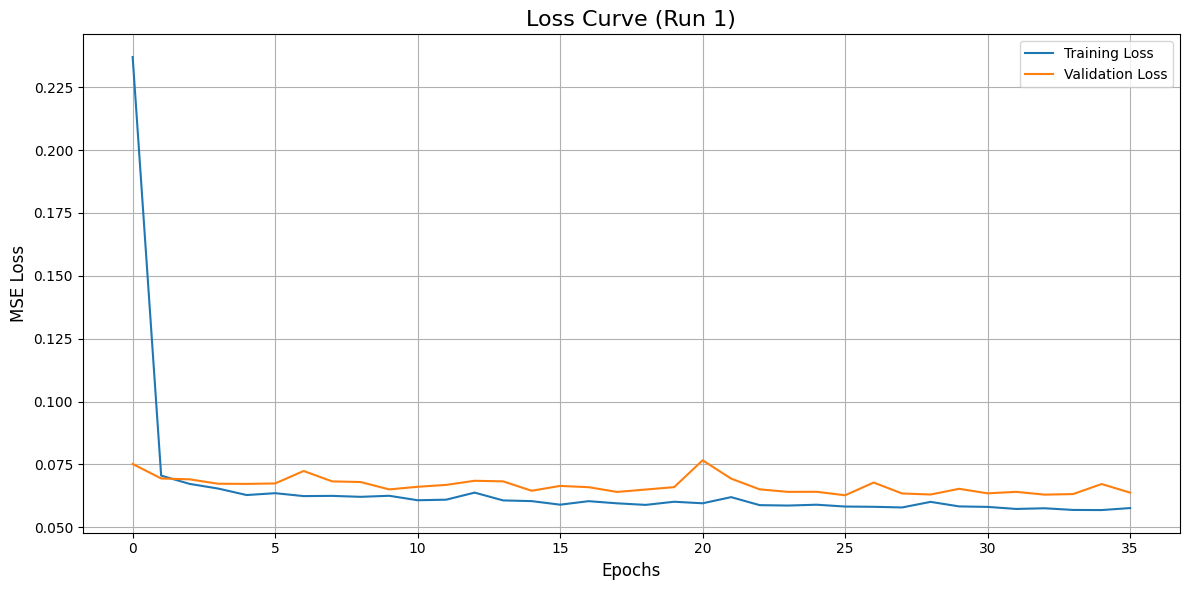

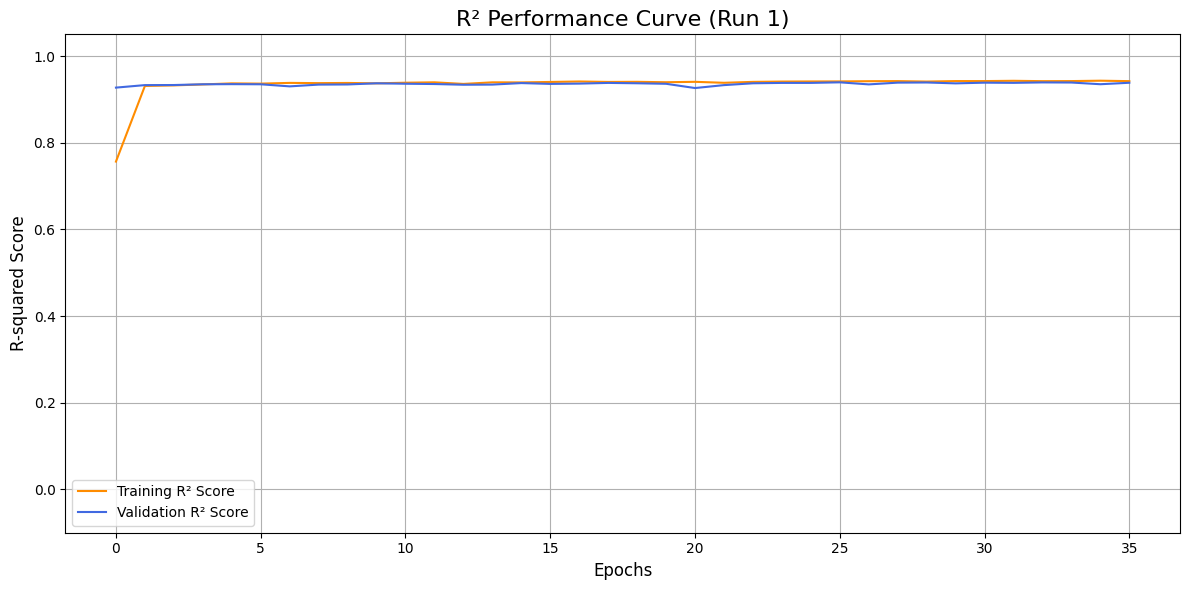

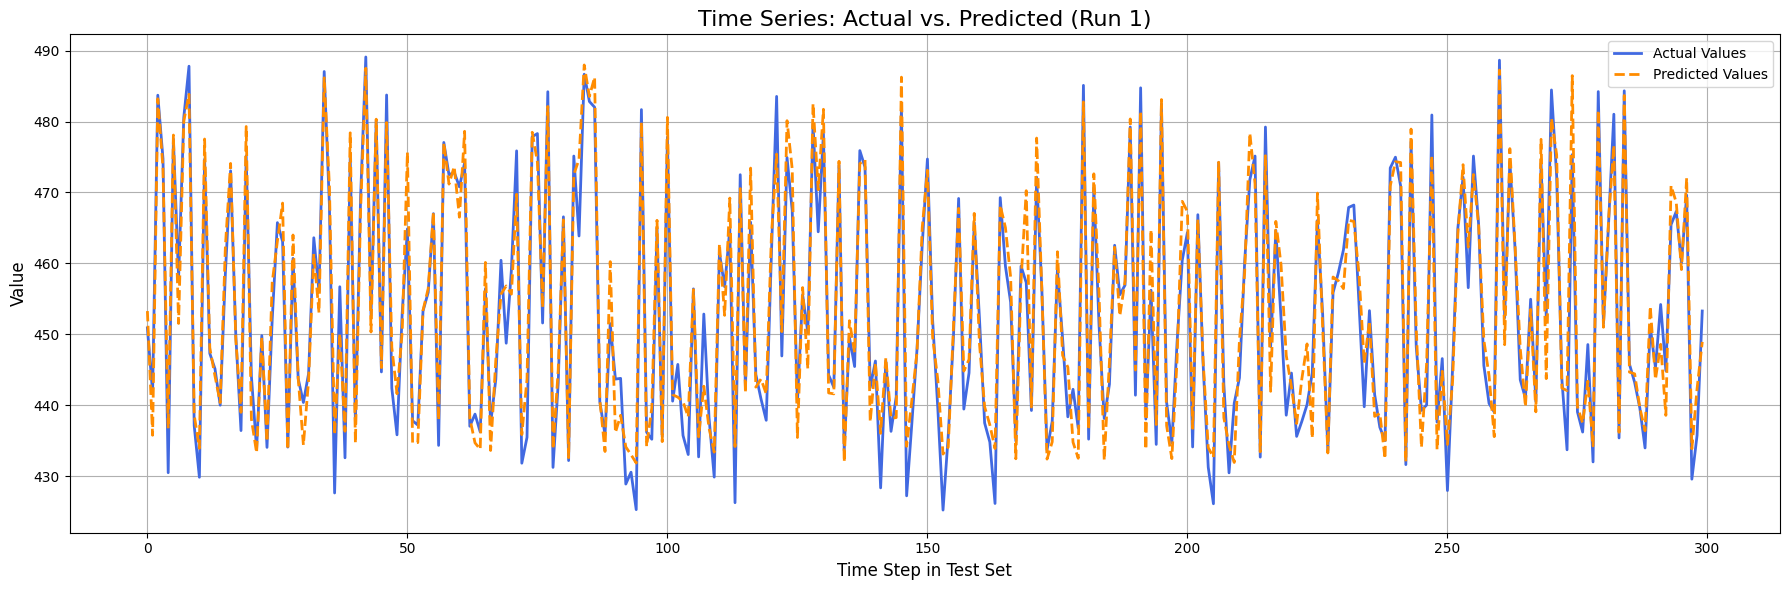



--- 🏆 FINAL MODEL RESULTS --- 
               Model          Avg_MSE          Avg_R2
Proposed_Hybrid_CCPP 16.7168 ± 0.0000 0.9407 ± 0.0000


--- 🧐 Starting Interpretability & Model Analysis --- 
✅ Best model loaded for analysis.

--- 🔢 Quantitative Dimensionality Analysis --- 
Original feature dimension: 4 | Learned embedding dimension: 512

-------------------- INSIGHT (PCA) --------------------
Effective dimensionality (d95): 7. The essential information from the 512-D embedding space can be compressed into just 7 dimensions, proving effective dimensionality reduction.
---------------------------------------------------------

-------------------- INSIGHT (Trustworthiness) --------------------
Trustworthiness score (k=10): 0.9981. This high score (close to 1.0) proves the model's compression was intelligent, preserving the data's essential local structure.
---------------------------------------------------------------------


--- 🧠 SHAP Feature Importance Analysis --- 


TypeError: Unknown type passed as data object: <class 'torch.Tensor'>

In [ ]:
# CCPP_Comprehensive_Analysis_Pipeline.py

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
import matplotlib.pyplot as plt
import os
import pickle
import seaborn as sns
import shap
from tqdm import tqdm
import requests
from zipfile import ZipFile
from io import BytesIO

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- 🚀 Training Proposed Model on CCPP Data ---")
print(f"Using device: {DEVICE}")

# Model & Training Hyperparameters
HIDDEN_DIM = 128
N_HEADS = 4
N_LAYERS = 2
DROPOUT_RATE = 0.2
EPOCHS = 60
BATCH_SIZE = 256
PATIENCE = 10
LEARNING_RATE = 0.001
NUM_NEIGHBORS = 4
NUM_RUNS = 1

# --- Plotting Functions ---
def plot_loss_curve(history, run_number):
    plt.figure(figsize=(12, 6));
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Curve (Run {run_number})', fontsize=16)
    plt.xlabel('Epochs', fontsize=12); plt.ylabel('MSE Loss', fontsize=12)
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(f'ccpp_loss_curve_run_{run_number}.png'); plt.show(); plt.close()

def plot_performance_curve(history, run_number):
    plt.figure(figsize=(12, 6))
    plt.plot(history['train_r2'], label='Training R² Score', color='darkorange')
    plt.plot(history['val_r2'], label='Validation R² Score', color='royalblue')
    plt.title(f'R² Performance Curve (Run {run_number})', fontsize=16)
    plt.xlabel('Epochs', fontsize=12); plt.ylabel('R-squared Score', fontsize=12)
    plt.ylim(-0.1, 1.05)
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(f'ccpp_performance_curve_run_{run_number}.png'); plt.show(); plt.close()

def plot_time_series(truths, preds, run_number):
    sample_points_to_plot = 300
    plt.figure(figsize=(18, 6))
    plt.plot(truths[-sample_points_to_plot:], label='Actual Values', color='royalblue', linewidth=2)
    plt.plot(preds[-sample_points_to_plot:], label='Predicted Values', color='darkorange', linestyle='--', linewidth=2)
    plt.title(f'Time Series: Actual vs. Predicted (Run {run_number})', fontsize=16)
    plt.xlabel('Time Step in Test Set', fontsize=12); plt.ylabel('Value', fontsize=12)
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(f'ccpp_time_series_run_{run_number}.png'); plt.show(); plt.close()


# --- Model and Helper Classes ---
class NeighborFinder:
    def __init__(self, adj_list): self.adj_list = adj_list
    def get_temporal_neighbor(self, src_idx_l, cut_time_l, num_neighbors=20):
        out_ngh_node_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.int64); out_ngh_ts_batch = np.zeros((len(src_idx_l), num_neighbors)).astype(np.float64)
        for i, (src_idx, cut_time) in enumerate(zip(src_idx_l, cut_time_l)):
            neighbors = self.adj_list.get(src_idx, [])
            recent_neighbors = sorted([n for n in neighbors if n[1] <= cut_time], key=lambda x: x[1], reverse=True)[:num_neighbors]
            if recent_neighbors:
                out_ngh_node_batch[i, :len(recent_neighbors)] = [x[0] for x in recent_neighbors]; out_ngh_ts_batch[i, :len(recent_neighbors)] = [x[1] for x in recent_neighbors]
        return out_ngh_node_batch, out_ngh_ts_batch

class SinusoidalTimeEncode(nn.Module):
    def __init__(self, dimension): super().__init__(); self.dimension = dimension
    def forward(self, t):
        t = t.unsqueeze(dim=-1); div = torch.exp(torch.arange(0, self.dimension, 2, device=DEVICE).float() * -(np.log(10000.0) / self.dimension)); pe = torch.zeros(*t.shape[:2], self.dimension, device=DEVICE); pe[..., 0::2] = torch.sin(t * div); pe[..., 1::2] = torch.cos(t * div); return pe

class TemporalAttentionLayer(nn.Module):
    def __init__(self, feat_dim, n_heads, dropout):
        super().__init__(); self.h, self.d = n_heads, feat_dim // n_heads; self.q_proj, self.k_proj, self.v_proj = (nn.Linear(feat_dim, feat_dim) for _ in range(3)); self.t_proj = nn.Linear(feat_dim, feat_dim); self.o_proj = nn.Linear(feat_dim, feat_dim); self.dropout = nn.Dropout(dropout)
    def forward(self, src_feat, ngh_feat, t_enc):
        b, n_ngh, _ = ngh_feat.size(); q = self.q_proj(src_feat).view(b, self.h, self.d).unsqueeze(2); k = self.k_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3); v = self.v_proj(ngh_feat).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3); t = self.t_proj(t_enc).view(b, n_ngh, self.h, self.d).permute(0, 2, 1, 3); scores = torch.sum((q * k) + t, dim=-1) / np.sqrt(self.d); attn = torch.softmax(scores, dim=-1); out = torch.sum(attn.unsqueeze(-1) * v, dim=2); return self.dropout(self.o_proj(out.view(b, -1)))

class TGAT_MHSA_BiLSTM(nn.Module):
    def __init__(self, neighbor_finder, node_features, feat_dim, n_layers, n_heads, dropout, bilstm_h, num_direct_features):
        super().__init__(); self.neighbor_finder = neighbor_finder; self.node_features = torch.nn.Parameter(node_features, requires_grad=False); self.embed_dim = bilstm_h * 2; self.feat_proj = nn.Linear(feat_dim, self.embed_dim); self.time_enc = SinusoidalTimeEncode(self.embed_dim); self.attn_layers = nn.ModuleList([TemporalAttentionLayer(self.embed_dim, n_heads, dropout) for _ in range(n_layers)]); self.norm_layers = nn.ModuleList([nn.LayerNorm(self.embed_dim) for _ in range(n_layers)]); self.mhsa = nn.MultiheadAttention(bilstm_h * 2, num_heads=n_heads, batch_first=True, dropout=dropout); self.bilstm = nn.LSTM(bilstm_h * 2, bilstm_h, batch_first=True, bidirectional=True); self.seq_norm = nn.LayerNorm(bilstm_h * 2); self.direct_feature_proj = nn.Sequential(nn.Linear(num_direct_features, bilstm_h), nn.ReLU(), nn.Linear(bilstm_h, bilstm_h * 2)); self.reg_head = nn.Sequential(nn.Linear(bilstm_h * 4, bilstm_h * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h * 2, bilstm_h), nn.GELU(), nn.Dropout(dropout), nn.Linear(bilstm_h, 1))
    def forward(self, src_nodes, timestamps, direct_features, return_representation=False):
        src_feat = self.feat_proj(self.node_features[src_nodes]); layer_outputs = []
        for i in range(len(self.attn_layers)):
            ngh_idx, ngh_ts = self.neighbor_finder.get_temporal_neighbor(src_nodes.cpu().numpy(), timestamps.cpu().numpy(), NUM_NEIGHBORS); ngh_idx_t = torch.from_numpy(ngh_idx).long().to(DEVICE); ngh_feat = self.feat_proj(self.node_features[ngh_idx_t.flatten()]).view(len(src_nodes), NUM_NEIGHBORS, -1); t_deltas = timestamps.unsqueeze(1) - torch.from_numpy(ngh_ts).float().to(DEVICE); t_enc = self.time_enc(t_deltas); mask = (ngh_idx_t != 0).unsqueeze(-1); agg_embed = self.attn_layers[i](src_feat, ngh_feat * mask, t_enc); src_feat = self.norm_layers[i](agg_embed + src_feat); layer_outputs.append(src_feat)
        tgat_sequence = torch.stack(layer_outputs, dim=1); mhsa_out, _ = self.mhsa(tgat_sequence, tgat_sequence, tgat_sequence); mhsa_sequence = self.seq_norm(tgat_sequence + mhsa_out); bilstm_out, _ = self.bilstm(mhsa_sequence); graph_representation = torch.mean(bilstm_out, dim=1); direct_representation = self.direct_feature_proj(direct_features); combined_representation = torch.cat([graph_representation, direct_representation], dim=1)
        if return_representation: return combined_representation
        return self.reg_head(combined_representation)

# --- Training and Evaluation ---
def train_and_evaluate(model, train_loader, val_loader, test_loader, run_number, target_scaler):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4); scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS); criterion = nn.MSELoss(); best_val_loss, patience_counter = float('inf'), 0
    history = {'train_loss': [], 'val_loss': [], 'train_r2': [], 'val_r2': []}
    for epoch in range(EPOCHS):
        model.train(); total_train_loss = 0; train_preds, train_truths = [], []
        for u, ts, df, y in train_loader:
            optimizer.zero_grad(); pred = model(u.to(DEVICE), ts.to(DEVICE), df.to(DEVICE)); loss = criterion(pred, y.to(DEVICE)); loss.backward(); optimizer.step()
            total_train_loss += loss.item(); train_preds.append(pred.cpu().detach()); train_truths.append(y.cpu().detach())
        history['train_loss'].append(total_train_loss / len(train_loader)); history['train_r2'].append(r2_score(torch.cat(train_truths), torch.cat(train_preds)))
        model.eval(); total_val_loss = 0; val_preds, val_truths = [], []
        with torch.no_grad():
            for u, ts, df, y in val_loader:
                pred = model(u.to(DEVICE), ts.to(DEVICE), df.to(DEVICE)); total_val_loss += criterion(pred, y.to(DEVICE)).item(); val_preds.append(pred.cpu()); val_truths.append(y.cpu())
        avg_val_loss = total_val_loss / len(val_loader); history['val_loss'].append(avg_val_loss); history['val_r2'].append(r2_score(torch.cat(val_truths), torch.cat(val_preds)))
        print(f"Epoch {epoch+1:02d}/{EPOCHS} -> Train Loss: {history['train_loss'][-1]:.4f}, Val Loss: {avg_val_loss:.4f} | Train R²: {history['train_r2'][-1]:.4f}, Val R²: {history['val_r2'][-1]:.4f}")
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss; torch.save(model.state_dict(), f'best_model_ccpp_run_{run_number}.pth'); patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= PATIENCE: print(f"Early stopping at epoch {epoch+1}"); break
        scheduler.step()
    model.load_state_dict(torch.load(f'best_model_ccpp_run_{run_number}.pth')); model.eval(); preds_list, truths_list = [], []
    with torch.no_grad():
        for u, ts, df, y in test_loader: preds_list.append(model(u.to(DEVICE), ts.to(DEVICE), df.to(DEVICE)).cpu()); truths_list.append(y.cpu())
    preds = target_scaler.inverse_transform(torch.cat(preds_list).numpy()); truths = target_scaler.inverse_transform(torch.cat(truths_list).numpy())
    if run_number == 1:
        print("\n--- 📊 Generating plots for Run 1 ---"); plot_loss_curve(history, run_number); plot_performance_curve(history, run_number); plot_time_series(truths, preds, run_number)
    return {'mse': mean_squared_error(truths, preds), 'r2': r2_score(truths, preds)}

def analyze_model_and_interpret(model_path, model, train_loader, test_loader, feature_names):
    print("\n\n" + "="*80 + "\n--- 🧐 Starting Interpretability & Model Analysis --- \n" + "="*80)
    model.load_state_dict(torch.load(model_path)); model.eval(); print("✅ Best model loaded for analysis.")
    # --- 1. Quantitative Dimensionality Analysis ---
    print("\n" + "="*50 + "\n--- 🔢 Quantitative Dimensionality Analysis --- \n" + "="*50)
    sample_size = 1000; test_subset_indices = list(range(sample_size)); u, ts, df, y = test_loader.dataset[test_subset_indices]
    with torch.no_grad(): learned_embeddings = model(u.to(DEVICE), ts.to(DEVICE), df.to(DEVICE), return_representation=True).cpu().numpy(); raw_features = df.cpu().numpy()
    print(f"Original feature dimension: {raw_features.shape[1]} | Learned embedding dimension: {learned_embeddings.shape[1]}")
    # A. Intrinsic Dimensionality (PCA)
    pca = PCA(); pca.fit(learned_embeddings); cumulative_variance = np.cumsum(pca.explained_variance_ratio_); d95 = np.argmax(cumulative_variance >= 0.95) + 1
    print("\n" + "-"*20 + " INSIGHT (PCA) " + "-"*20 + f"\nEffective dimensionality (d95): {d95}. The essential information from the {learned_embeddings.shape[1]}-D embedding space can be compressed into just {d95} dimensions, proving effective dimensionality reduction.\n" + "-"*57)
    # B. Neighborhood Preservation (Trustworthiness)
    n_neighbors = 10  # <<< MODIFIED
    trust_score = trustworthiness(raw_features, learned_embeddings, n_neighbors=n_neighbors)
    print("\n" + "-"*20 + " INSIGHT (Trustworthiness) " + "-"*20 + f"\nTrustworthiness score (k={n_neighbors}): {trust_score:.4f}. This high score (close to 1.0) proves the model's compression was intelligent, preserving the data's essential local structure.\n" + "-"*69)
    # --- 2. SHAP Analysis for Feature Importance ---
    print("\n\n" + "="*50 + "\n--- 🧠 SHAP Feature Importance Analysis --- \n" + "="*50)
    background_data = next(iter(train_loader)); u_bg, ts_bg, df_bg, _ = background_data; background_summary = shap.sample(df_bg, 20)
    explain_data = next(iter(test_loader)); u_exp, ts_exp, df_exp, _ = explain_data
    def predictor(features_numpy):
        num_perturbations = features_numpy.shape[0]; features_tensor = torch.from_numpy(features_numpy).float().to(DEVICE); u_tiled = u_exp[:num_perturbations].to(DEVICE); ts_tiled = ts_exp[:num_perturbations].to(DEVICE)
        with torch.no_grad(): predictions = model(u_tiled, ts_tiled, features_tensor)
        return predictions.cpu().numpy()
    explainer = shap.KernelExplainer(predictor, background_summary); shap_values = explainer.shap_values(df_exp, nsamples=50); print("✅ SHAP analysis complete.")
    shap.summary_plot(shap_values, features=df_exp, feature_names=feature_names, show=False); plt.tight_layout(); plt.savefig("ccpp_shap_summary.png"); plt.show(); plt.close()

if __name__ == '__main__':
    # --- Data Loading and Preparation ---
    try:
        node_features_array = np.load('nodes_power_tgat.npy');
        with open('adj_list_power_tgat.pkl', 'rb') as f: adj_list = pickle.load(f)
        if not os.path.exists('CCPP/Folds5x2_pp.xlsx'):
            print("Downloading CCPP data..."); response = requests.get('https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'); response.raise_for_status()
            with ZipFile(BytesIO(response.content)) as z: z.extractall()
        original_df = pd.read_excel('CCPP/Folds5x2_pp.xlsx')
    except FileNotFoundError: print("❌ ERROR: Data not found. Run preprocessing script first."); sys.exit()
    target = original_df[['PE']].values; direct_features = original_df[['AT', 'V', 'AP', 'RH']].values; feature_names=['AT', 'V', 'AP', 'RH']
    feature_scaler = StandardScaler().fit(direct_features); target_scaler = StandardScaler().fit(target)
    direct_features_scaled = feature_scaler.transform(direct_features); target_scaled = target_scaler.transform(target)
    node_ids = np.full(len(original_df), 4); timestamps = np.arange(len(original_df))
    node_features = torch.tensor(node_features_array, dtype=torch.float32)
    full_ds = TensorDataset(torch.from_numpy(node_ids).long(), torch.from_numpy(timestamps).float(), torch.from_numpy(direct_features_scaled).float(), torch.from_numpy(target_scaled).float())
    train_size, val_size = int(len(original_df) * 0.7), int(len(original_df) * 0.15)
    train_ds, val_ds, test_ds = Subset(full_ds, range(train_size)), Subset(full_ds, range(train_size, train_size + val_size)), Subset(full_ds, range(train_size + val_size, len(original_df)))
    train_loader, val_loader, test_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True), DataLoader(val_ds, BATCH_SIZE), DataLoader(test_ds, BATCH_SIZE)
    # --- Model Initialization and Execution ---
    run_metrics = {'mse': [], 'r2': []}; model_path = ""
    model_args = {'neighbor_finder': NeighborFinder(adj_list), 'node_features': node_features, 'feat_dim': node_features.shape[1], 'n_layers': N_LAYERS, 'n_heads': N_HEADS, 'dropout': DROPOUT_RATE, 'bilstm_h': HIDDEN_DIM, 'num_direct_features': len(feature_names)}
    for i in range(1, NUM_RUNS + 1):
        model = TGAT_MHSA_BiLSTM(**model_args).to(DEVICE); model_path = f'best_model_ccpp_run_{i}.pth'
        metrics = train_and_evaluate(model, train_loader, val_loader, test_loader, i, target_scaler)
        for key, value in metrics.items(): run_metrics[key].append(value)
    # --- Final Results and Analysis ---
    avg_metrics = { 'Model': 'Proposed_Hybrid_CCPP', **{f'Avg_{k.upper()}': f"{np.mean(v):.4f} ± {np.std(v):.4f}" for k, v in run_metrics.items()}}
    print("\n\n" + "="*80 + "\n--- 🏆 FINAL MODEL RESULTS --- \n" + "="*80); print(pd.DataFrame([avg_metrics]).to_string(index=False)); print("="*80)
    if NUM_RUNS > 0:
        analyze_model_and_interpret(model_path, TGAT_MHSA_BiLSTM(**model_args).to(DEVICE), train_loader, test_loader, feature_names)